# HANK model with energy: IRFs

Selma Malmberg & François Langot

January 2025

The aim of this notebook is to solve a HANK model with energy, calibrate it using French data and see the impulse response functions to some energy shocks.

### Table of content
0. [Set up](#0-setup)
1. [Heterogeneous households](#1-HA)
2. [Steady-state](#2-SS)
3. [Dynamics](#3-dynamics)
4. [Linear vs non-linear IRFs](#4-IRFs)
5. [Tariff shield effect](#5-TS)
5. [Inequalities](#6-Ineq)

<a id="0-setup"></a>
## 0 Set up

In [1]:
# Python libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import string

In [2]:
# Auclert et al's toolbox
import sequence_jacobian as ssj

In [3]:
# Selma's codes
import TOOLS.IRFs as irf
import TOOLS.inequality as ineq

Set the following variables to True or False:
- `save_fig`: True to save the charts

In [5]:
save_fig = False

In [6]:
# For LaTeX font on figures
plt.rc('text', usetex=False)
plt.rc('font', family='serif')

<a id="1-HA"></a>
## 1 Heterogeneous households

In [7]:
# Import the households' block
from CepreHANKv1 import household

In [8]:
print('Inputs: ', *household.inputs)
print('Outputs: ', *household.outputs)

Inputs:  beta eis cbar pFE_HA w r taul tauc L YFE YF Div Tax Trans Subv Subv1 Subv2 rho_s sigma_s nS amin amax nA
Outputs:  A C C_TOT N NS INC CFE CH C_0 C_1 C_2 C_3 C_4 C_5 C_6 CTOT_0 CTOT_1 CTOT_2 CTOT_3 CTOT_4 CTOT_5 CTOT_6 A_0 A_1 A_2 A_3 A_4 A_5 A_6 N_0 N_1 N_2 N_3 N_4 N_5 N_6 NS_0 NS_1 NS_2 NS_3 NS_4 NS_5 NS_6 INC_0 INC_1 INC_2 INC_3 INC_4 INC_5 INC_6 CFE_0 CFE_1 CFE_2 CFE_3 CFE_4 CFE_5 CFE_6 CH_0 CH_1 CH_2 CH_3 CH_4 CH_5 CH_6


<a id="2-SS"></a>
## 2 Steady state

In [9]:
calibration = {# Targets
               'r': 0.005, 'L': 1.0, 
               'se': 0.087, 'sce': (0.087 / 2) * 0.4,
               # Fiscal policy
               'B_b': 4, 'B_g': 0.2, 'B_t': 0.25, 
               'sH': 0, 'sF': 1e-50,
               'tauc': 0.2, 'taul': 0.2, 'tau1': 0.1, 'χl': 1e-10, 'χc': 1e-10,
               # NKPCs
               'kappa': 0.95, 'mu': 1.2, 'kappaw': 0.1, 'muw': 1.1,
               # Utility
               'eis': 1, 'frisch': 0.5,
               # Production
               'alpphaE': 0.025, 'etaE': 0.5, 
               'share': 0.5,
               # Taylor rule
               'phi': 1.2, 'phiy': 0.0, 'rhor': 0.85,
               # Grids
               'nA': 500, 'amin': 0, 'amax': 300,
               'nS': 7, 'rho_s': 0.966, 'sigma_s': 0.5
}

unknowns_ss = {'beta': 0.9922005057100952, 'vphi': 0.6348672836874902, 'Tax': 0.18375887656711004}
targets_ss  = {'asset_mkt': 0.0, 'labour_mkt': 0.0, 'balanced_bud': 0.0}

In [10]:
# Solve the steady-state
from CepreHANKv1 import model_ss, market_clearing_ss
# model_ss.solve_steady_state_options['verbose'] = True
ss = model_ss.solve_steady_state(calibration=calibration, unknowns=unknowns_ss, targets=targets_ss)

In [11]:
# Table 2: Calibrated parameters
print('------ Table 2: Calibrated parameters ------')
print('Discount factor:', np.round(ss['beta'], 4))
print('Real rate:', np.round(ss['r'], 4))
print('Disutility of labor:', np.round(ss['vphi'], 4))
print('Aggregate labor:', np.round(ss['L'], 4))
print('Frisch elasticity:', np.round(ss['frisch'], 4))
print('Incompressible energy consumption:', np.round(ss['cbar'], 4))
print('40% of Household energy consumption:', np.round(0.4*ss['YFE'], 4))
print('Wage markup:', np.round(ss['muw'], 4))
print('Elasticity of subsitution between production inputs:', np.round(ss['etaE'], 4))
print('Share parameter (energy, intermediate good):', np.round(ss['alpphaE'], 4))
print('Household energy share:', np.round(ss['YFE']/ss['Esupply'], 4))
print('Share parameter (energy, labor):', np.round(ss['alpphaf'], 4))
print('Price markup:', np.round(ss['mu'], 4))
print('Energy (% GDP):', np.round(ss['pFE']*ss['Esupply']/ss['Y'], 4))
print('Public debt:', np.round(ss['B'], 4))
print('Public debt (% GDP):', np.round(ss['B']/(4*ss['Y']), 4))
print('Public spending:', np.round(ss['G'], 4))
print('Public spending (% GDP):', np.round(ss['G']/ss['Y'], 4))
print('Transfers:', np.round(ss['Trans'], 4))
print('Transfers (% GDP):', np.round(ss['Trans']/ss['Y'], 4))
print('VAT rate:', np.round(ss['tauc'], 4))
print('Income tax rate:', np.round(ss['taul'], 4))
print('Price rigidity:', np.round(ss['kappa'], 4))
print('Wage rigidity:', np.round(ss['kappaw'], 4))
print('Taylor rule coefficient:', np.round(ss['phi'], 4))
print('Persistence of monetary policy:', np.round(ss['rhor'], 4))
print('Income process persistence:', np.round(ss['rho_s'], 4))
print('Income process volatility:', np.round(ss['sigma_s'], 4))

------ Table 2: Calibrated parameters ------
Discount factor: 0.9926
Real rate: 0.005
Disutility of labor: 0.6503
Aggregate labor: 1.0
Frisch elasticity: 0.5
Incompressible energy consumption: 0.0048
40% of Household energy consumption: 0.0048
Wage markup: 1.1
Elasticity of subsitution between production inputs: 0.5
Share parameter (energy, intermediate good): 0.025
Household energy share: 0.5
Share parameter (energy, labor): 0.0256
Price markup: 1.2
Energy (% GDP): 0.087
Public debt: 3.9694
Public debt (% GDP): 1.0
Public spending: 0.1985
Public spending (% GDP): 0.2
Transfers: 0.2481
Transfers (% GDP): 0.25
VAT rate: 0.2
Income tax rate: 0.2
Price rigidity: 0.95
Wage rigidity: 0.1
Taylor rule coefficient: 1.2
Persistence of monetary policy: 0.85
Income process persistence: 0.966
Income process volatility: 0.5


### Inequalities statistics

In [12]:
# Table 14: Income inequalities (Model columns)
inc_dec = ineq.variable_deciles(ss.internals['household']['e_grid'], ss.internals['household']['pi_e'], 'Labor income', tol=1e-10)
inc_stats = np.array(inc_dec.rolling(2).mean().dropna().reset_index(drop=True).rolling(2).mean().dropna().reset_index(drop=True).iloc[[0, 1, 3, 5, 7]]) # Compute bin averages
print('------ Table 14: Income inequalities (Model columns) ------')
print('Lower than D2', np.round(inc_stats[0], 4), np.round(inc_stats[0]/inc_stats[2], 4))
print('D2-D3', np.round(inc_stats[1], 4), np.round(inc_stats[1]/inc_stats[2], 4))
print('D4-D5', np.round(inc_stats[2], 4), np.round(inc_stats[2]/inc_stats[2], 4))
print('D6-D7', np.round(inc_stats[3], 4), np.round(inc_stats[3]/inc_stats[2], 4))
print('D8-D9', np.round(inc_stats[4], 4), np.round(inc_stats[4]/inc_stats[2], 4))
print('Greater than D9', np.round(0.5*(inc_dec.loc['D9'].values+inc_dec.loc['Max'].values), 4), np.round(0.5*(inc_dec.loc['D9'].values+inc_dec.loc['Max'].values)/inc_stats[2], 4))

------ Table 14: Income inequalities (Model columns) ------
Lower than D2 [0.4069] [0.5028]
D2-D3 [0.538] [0.6648]
D4-D5 [0.8092] [1.]
D6-D7 [0.9946] [1.229]
D8-D9 [1.496] [1.8487]
Greater than D9 [2.5022] [3.092]


/Users/selmamalmberg/Downloads/TariffShield/TOOLS/inequality.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [13]:
# Table 15: Consumption inequalities (Model row)
c_dec = ineq.variable_deciles(ss.internals['household']['c'], ss.internals['household']['D'], label='Consumption')
print('------ Table 15: Consumption inequalities (Model row) ------')
print('D1/D5', np.round((c_dec.loc['D1']/c_dec.loc['D5']).values, 4))
print('D2/D5', np.round((c_dec.loc['D2']/c_dec.loc['D5']).values, 4))
print('D3/D5', np.round((c_dec.loc['D3']/c_dec.loc['D5']).values, 4))
print('D4/D5', np.round((c_dec.loc['D4']/c_dec.loc['D5']).values, 4))
print('D6/D5', np.round((c_dec.loc['D6']/c_dec.loc['D5']).values, 4))
print('D7/D5', np.round((c_dec.loc['D7']/c_dec.loc['D5']).values, 4))
print('D8/D5', np.round((c_dec.loc['D8']/c_dec.loc['D5']).values, 4))
print('D9/D5', np.round((c_dec.loc['D9']/c_dec.loc['D5']).values, 4))

------ Table 15: Consumption inequalities (Model row) ------
D1/D5 [0.7484]
D2/D5 [0.7608]
D3/D5 [0.9062]
D4/D5 [0.9297]
D6/D5 [1.0751]
D7/D5 [1.1265]
D8/D5 [1.2127]
D9/D5 [1.32]


/Users/selmamalmberg/Downloads/TariffShield/TOOLS/inequality.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [14]:
# Table 16: Wealth inequalities (Model columns)
a_dec = ineq.variable_deciles(ss.internals['household']['a'], ss.internals['household']['D'], label='Wealth')
ref = 0.5*(a_dec.loc['D5'].values + a_dec.loc['D6']).values
print('------ Table 16: Wealth inequalities (Model columns) ------')
print('Lower than D2', np.round(a_dec.loc['D2'].values, 4), np.round(a_dec.loc['D2'].values/ref, 4))
print('D2-D4', np.round(0.5*(a_dec.loc['D3'].values + a_dec.loc['D4'].values), 4), np.round(0.5*(a_dec.loc['D3'].values + a_dec.loc['D4'].values) / ref, 4))
print('D4-D6', np.round(ref, 4), np.round(ref/ref, 4))
print('D6-D8', np.round(0.5*(a_dec.loc['D7'].values + a_dec.loc['D8'].values), 4), np.round(0.5*(a_dec.loc['D7'].values + a_dec.loc['D8'].values) / ref, 4))
print('D8-D9', np.round(0.5*(a_dec.loc['D8'].values + a_dec.loc['D9'].values), 4), np.round(0.5*(a_dec.loc['D8'].values + a_dec.loc['D9'].values) / ref, 4))
print('Greater than D9', np.round(a_dec.loc['D9'].values, 4), np.round(a_dec.loc['D9'].values / ref, 4))

------ Table 16: Wealth inequalities (Model columns) ------
Lower than D2 [0.0062] [0.0033]
D2-D4 [0.3207] [0.1726]
D4-D6 [1.8575] [1.]
D6-D8 [5.495] [2.9582]
D8-D9 [9.3009] [5.0071]
Greater than D9 [11.744] [6.3223]


/Users/selmamalmberg/Downloads/TariffShield/TOOLS/inequality.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [15]:
# Table 17: Shares represented by each earning groups
print('------ Table 17: Earning groups definition ------')
100 * ss.internals['household']['pi_e'].cumsum()

------ Table 17: Earning groups definition ------


array([  1.5625    ,  10.93750001,  34.37500001,  65.62499999,
        89.06249999,  98.4375    , 100.        ])

In [16]:
c_dec = ineq.variable_deciles(ss.internals['household']['c'], ss.internals['household']['D'], label='Consumption') # Compute bin averages
c_stats = np.array(c_dec.rolling(2).mean().dropna().reset_index(drop=True).rolling(2).mean().dropna().reset_index(drop=True).iloc[[0, 1, 3, 5, 7]])

/Users/selmamalmberg/Downloads/TariffShield/TOOLS/inequality.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [17]:
# Table 18: Consumption inequalities
print('------ Table 18: Consumption inequalities conditional on consumption ------')
c_dec = ineq.variable_deciles(ss.internals['household']['c'], ss.internals['household']['D'], label='Consumption') # Compute bin averages
c_stats = np.array(c_dec.rolling(2).mean().dropna().reset_index(drop=True).rolling(2).mean().dropna().reset_index(drop=True).iloc[[0, 1, 3, 5, 7]])
print('Q1/D5', np.round((0.5*(c_dec.loc['D2']+c_dec.loc['D3'])/ c_dec.loc['D5']).values, 4))
print('Q2/D5', np.round((0.5*(c_dec.loc['D6']+c_dec.loc['D7'])/ c_dec.loc['D5']).values, 4))
print('Q3/D5', np.round((0.5*(c_dec.loc['D9']+c_dec.loc['Max'])/ c_dec.loc['D5']).values, 4))


------ Table 18: Consumption inequalities conditional on consumption ------
Q1/D5 [0.8335]
Q2/D5 [1.1008]
Q3/D5 [1.9535]


/Users/selmamalmberg/Downloads/TariffShield/TOOLS/inequality.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [18]:
# Table 18: Consumption inequalities
# Average consumption by income deciles
c_dec2 = ineq.variable_deciles(np.array([ss['C_{}'.format(i)]/ss.internals['household']['pi_e'][i] for i in range(7)]),
                                               ss.internals['household']['pi_e'], 'Average consumption per income deciles',
                                               tol=1e-10)
c_stats2 = np.array(c_dec2.rolling(2).mean().dropna().reset_index(drop=True).rolling(2).mean().dropna().reset_index(drop=True).iloc[[0, 1, 3, 5, 7]]) # Compute bin averages
print('------ Table 18: Consumption inequalities conditional on income ------')
print('Q1/D5', np.round((0.5*(c_dec2.loc['D2']+c_dec2.loc['D3'])/c_dec2.loc['D5']).values, 4))
print('Q2/D5', np.round((0.5*(c_dec2.loc['D6']+c_dec2.loc['D7'])/c_dec2.loc['D5']).values, 4))
print('Q3/D5', np.round((0.5*(c_dec2.loc['D9']+c_dec2.loc['Max'])/c_dec2.loc['D5']).values, 4))

------ Table 18: Consumption inequalities conditional on income ------
Q1/D5 [0.8356]
Q2/D5 [1.0836]
Q3/D5 [1.4447]


/Users/selmamalmberg/Downloads/TariffShield/TOOLS/inequality.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


### MPCs and elasticities

In [19]:
# MPC total
def get_mpc(c, a, a_grid, r):
    """Approximate mpc, with symmetric differences where possible, exactly setting mpc=1 for constrained agents."""
    mpc = np.empty_like(c)
    post_return = (1 + r) * a_grid
    mpc[:, 1:-1] = (c[:, 2:] - c[:, 0:-2]) / (post_return[2:] - post_return[:-2])
    mpc[:, 0] = (c[:, 1] - c[:, 0]) / (post_return[1] - post_return[0])
    mpc[:, -1] = (c[:, -1] - c[:, -2]) / (post_return[-1] - post_return[-2])
    mpc[a == a_grid[0]] = 1
    return mpc 

# MPC energy
def get_energyelasticity(c, a_grid, r, alpphaE, pFE, etaE, cbar):
    cFE = alpphaE * (pFE ** (-etaE)) * c + cbar
    elast = np.empty_like(c)
    post_return = (1 + r) * a_grid
    elast[:, 1:-1] = (cFE[:, 2:] - cFE[:, 0:-2]) / (post_return[2:] - post_return[:-2])
    elast[:, 0] = (cFE[:, 1] - cFE[:, 0]) / (post_return[1] - post_return[0])
    elast[:, -1] = (cFE[:, -1] - cFE[:, -2]) / (post_return[-1] - post_return[-2])
    return elast

# Price elasticty
def get_priceelasticity(c1, c2, alpphaE, pFE1, pFE2, etaE, cbar):
    """Computes the price arc elasticity of energy consumption."""
    cFE1 = alpphaE * (pFE1 ** (-etaE)) * c1 + cbar
    cFE2 = alpphaE * (pFE2 ** (-etaE)) * c2 + cbar
    change_c = (cFE2 - cFE1) / ((cFE1 + cFE2)/2)
    change_p = (pFE2 - pFE1) / ((pFE1 + pFE2)/2)
    return change_c / change_p

# Share of energy in consumption
def get_energyshare(c, alpphaE, pFE, etaE, cbar):
    cFE = alpphaE * (pFE ** (-etaE)) * c + cbar
    return cFE / c

------ Figure 1a: Marginal propensity to consume ------


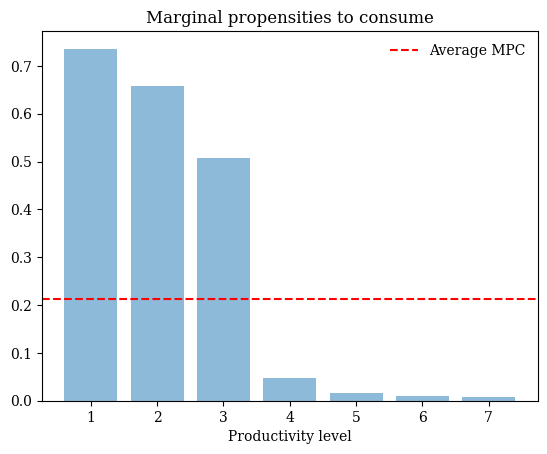

In [20]:
# Figure 1, panel a: MPCs
print('------ Figure 1a: Marginal propensity to consume ------')
mpc = get_mpc(ss.internals['household']['c'], ss.internals['household']['a'], ss.internals['household']['a_grid'], ss['r'])
MPC = np.sum(mpc * ss.internals['household']['D'])

mpc_tab = (mpc * ss.internals['household']['D']).sum(axis=1) / ss.internals['household']['pi_e']
plt.bar(range(1,8), mpc_tab, align='center', alpha=0.5)
plt.axhline(MPC, color='red', linestyle='--', label='Average MPC')
plt.title('Marginal propensities to consume')
plt.xlabel('Productivity level')
plt.legend(frameon=False)
if save_fig:
    plt.savefig('Figures/Figure1a.eps', dpi=600)
plt.show()

------ Figure 1c: Price elasticity of energy ------


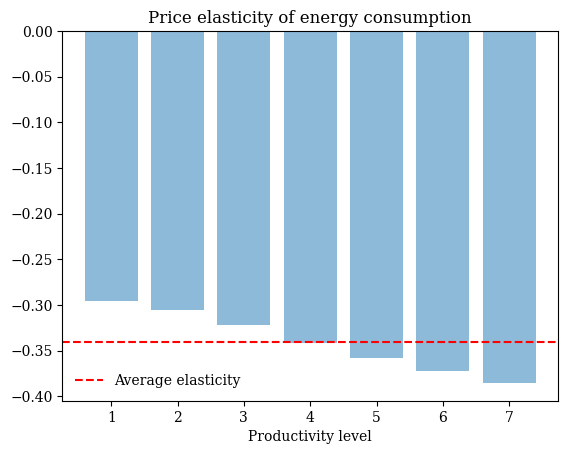

In [21]:
# Figure 1, panel c: Price elasticity of energy
print('------ Figure 1c: Price elasticity of energy ------')
calib = {}
for elem in ['beta', 'eis', 'frisch', 'vphi', 'cbar', 'pH', 'w', 'r', 'taul', 'tauc', 'L', 'YFE', 'YF', 'Div', 'Tax', 'Trans', 'Subv', 'Subv1', 'Subv2', 'rho_s', 'sigma_s', 'nS', 'amin', 'amax', 'nA']:
    calib[elem] = ss[elem]
calib['pFE_HA'] = ss['pFE_HA']*1.1

temp = household.steady_state(calib)

priceelast = get_priceelasticity(ss.internals['household']['c'], temp.internals['household']['c'], ss['alpphaE'], ss['pFE'], ss['pFE']*1.1, ss['etaE'], ss['cbar'])
PRICEELAST = np.sum(priceelast * ss.internals['household']['D'])

priceelast_tab = (priceelast * ss.internals['household']['D']).sum(axis=1) / ss.internals['household']['pi_e']
plt.bar(range(1,8), priceelast_tab, align='center', alpha=0.5)
plt.axhline(PRICEELAST, color='red', linestyle='--', label='Average elasticity')
plt.title('Price elasticity of energy consumption')
plt.xlabel('Productivity level')
plt.legend(frameon=False)
if save_fig:
    plt.savefig('Figures/Figure1c.eps', dpi=600)
plt.show()

------ Figure 1b: Energy expenditure ------


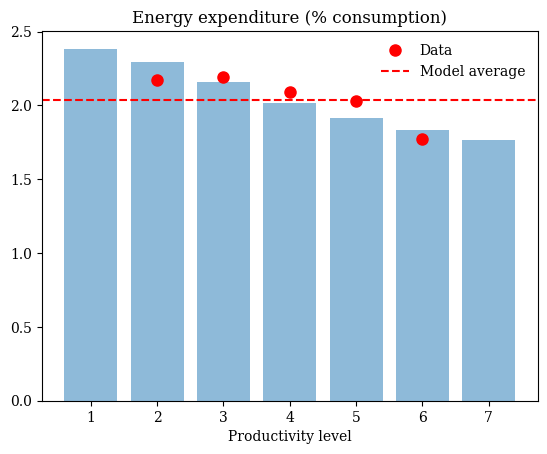

In [22]:
# Figure 1, panel b: Energy expenditure
print('------ Figure 1b: Energy expenditure ------')
energyshare = get_energyshare(ss.internals['household']['c'], ss['alpphaE'], ss['pFE'], ss['etaE'], ss['cbar'])
ENERGYSHARE = np.sum(energyshare * ss.internals['household']['D'])

# Data: Enquete budget des ménages 2017
cons = np.array([[27408, 16123, 18322, 20071, 22638, 23787, 27081, 29059, 32645, 35867, 48353], # total conso
                 [1353, 967, 1123, 1193, 1279, 1281, 1348, 1449, 1427, 1530, 1925],             # elec gaz fioul
                 [1108, 622, 754, 868, 1006, 1174, 1196, 1333, 1288, 1462, 1375],               # carburant
                 [9554, 2371, 2789, 3783, 4849, 5471, 7788, 10578, 11194, 16138, 30468],        # hors conso
                 [3437, 665, 625, 1002, 1198, 1439, 2210, 3040, 3754, 6019, 1436],              # impots
                 [2671, 674, 738, 1113, 1387, 1635, 2366, 3559, 3532, 4275, 7400],              # prêts
                 [1015, 340, 545, 655, 897, 909, 1147, 1159, 1211, 1419, 1861]])                # prêts conso
share_obs = (cons[1,1:-1]+cons[2,1:-1])/(cons[0,1:-1])

energyshare_tab = (energyshare * ss.internals['household']['D']).sum(axis=1) / ss.internals['household']['pi_e']

plt.plot(range(1,8), 100 * (ENERGYSHARE/np.mean(share_obs))*np.array([np.nan,share_obs[1],share_obs[4],np.mean(share_obs[4:6]),share_obs[6],share_obs[8],np.nan]),'or', markersize=8, label='Data')
plt.bar(range(1,8), 100 * energyshare_tab, align='center', alpha=0.5)
plt.axhline(100 * ENERGYSHARE, color='red', linestyle='--', label='Model average')
plt.title('Energy expenditure (% consumption)')
plt.xlabel('Productivity level')
plt.legend(frameon=False)
if save_fig:
    plt.savefig('Figures/Figure1b.eps', dpi=600)
plt.show()


<a id="3-dynamics"></a>

## 3 Dynamics

In [23]:
from CepreHANKv1 import subsidy, firm, energy_policy, nkpc, inflation, union, wage, mkt_clearing, household, definitions


In [24]:
@ssj.solved(unknowns={'i': 0.005}, targets=['i_res'])
def monetary(i, Y, pi, phi, phiy, rhor, i_shock):
    i_res = (1-rhor) * (ss['r'] + phi * pi + phiy * (Y - Y.ss) ) + rhor * i(-1) + i_shock - i 
    r     = (1 + i(-1))/(1 + pi) - 1
    return i_res, r

In [25]:
@ssj.simple
def fiscal(B, tau1, w, pFE, L, r, Dep, tauc, taul, Capprox, cbar, TransEXO, TaxEXO): 
    Trans    = TransEXO + ss['Trans'] - tau1 * ( B(-1)/B.ss -1 ) 
    Tax      = TaxEXO + ss['Tax']
    Recettes = Tax + taul * w * L + tauc * Capprox + tauc * pFE * cbar
    debt_res = (1 + r) * B(-1) - Recettes + (Dep + Trans) - B
    return debt_res, Trans, Tax, Recettes

In [26]:
exogenous   = ['rstar', 'Z', 'pFE', 'subv', 'G', 'mu', 'muw', 'beta', 'sF', 'TransEXO', 'TaxEXO', 'Subv', 'Subv1', 'Subv2', 'χl', 'χc']
unknowns    = ['pi', 'w', 'Y', 'Capprox', 'B', 'tauc', 'taul']
targets     = ['nkpc_res', 'asset_mkt', 'labour_mkt', 'conso', 'debt_res', 'tauc_res', 'taul_res']
block_list  = [subsidy, firm, energy_policy, monetary, fiscal, nkpc, inflation, union, wage, mkt_clearing, household, definitions]
model       = ssj.create_model(block_list, name='CepreHANK')

<a id="4-IRFs"></a>
## 4 Linear vs non-linear IRFs

### Energy shock

In [27]:
# Generate an energy shock
T = 500
truncated_T = 30
dpFE  = irf.shock_generator(ss, 'pFE', rho=.8, p=100/100, T=T, truncated_T=truncated_T, display=False).reshape(T)

In [28]:
var = ['pFE_HA', 'pi', 'i',
       'Y', 'E', 'L',
       'w', 'C', 'YFE']

var_names = ['Subsidized energy price', 'Inflation', 'Nominal interest rate',
             'Output', 'Energy input', 'Labor',
             'Real wage', 'Consumption', 'Household energy consumption'] 

In [29]:
# Linear IRFs
irfs_energy = model.solve_impulse_linear(ss, unknowns=unknowns, targets=targets,
                                         inputs={'pFE': dpFE})

### Tariff shield shock

In [30]:
# Generate a tariff shield shock
dpFE_HA  = irf.shock_generator(ss, 'pFE_HA', rho=.8, p=80/100, T=T, truncated_T=truncated_T, display=False).reshape(T)
dsubv    = dpFE - dpFE_HA

In [31]:
# Linear IRFs
irfs_ts = model.solve_impulse_linear(ss, unknowns=unknowns, targets=targets,
                                     inputs={'subv': dsubv})

In [32]:
# Non-linear IRFs
irfs_ts_nl = model.solve_impulse_nonlinear(ss, unknowns=unknowns, targets=targets,
                                           inputs={'subv': dsubv})

Solving CepreHANK for ['pi', 'w', 'Y', 'Capprox', 'B', 'tauc', 'taul'] to hit ['nkpc_res', 'asset_mkt', 'labour_mkt', 'conso', 'debt_res', 'tauc_res', 'taul_res']
Solving monetary_inner for ['i'] to hit ['i_res']
On iteration 0
   max error for i_res is 0.00E+00
On iteration 0
   max error for nkpc_res is 8.70E-03
   max error for asset_mkt is 2.81E-02
   max error for labour_mkt is 5.09E-04
   max error for conso is 2.16E-03
   max error for debt_res is 1.11E-02
   max error for tauc_res is 1.03E-12
   max error for taul_res is 1.03E-12
Solving monetary_inner for ['i'] to hit ['i_res']
On iteration 0
   max error for i_res is 1.00E-03
On iteration 1
   max error for i_res is 1.73E-18
On iteration 1
   max error for nkpc_res is 2.46E-05
   max error for asset_mkt is 9.21E-05
   max error for labour_mkt is 1.74E-05
   max error for conso is 2.48E-05
   max error for debt_res is 2.30E-04
   max error for tauc_res is 1.83E-15
   max error for taul_res is 1.80E-15
Solving monetary_inner fo

------ Figure 16a: Subsidized energy price ------


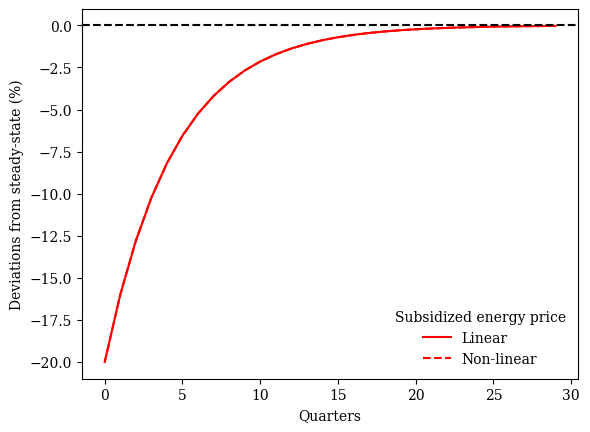

------ Figure 16b: Inflation ------


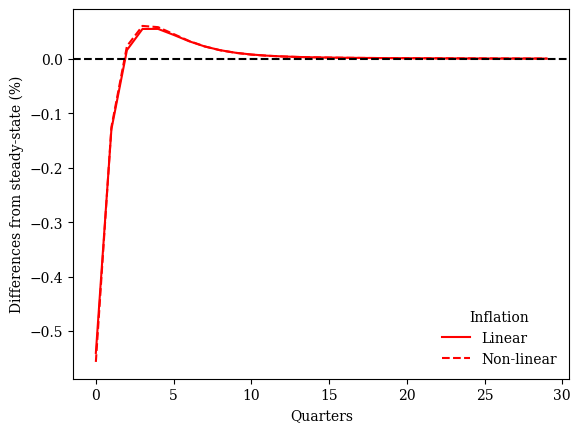

------ Figure 16c: Nominal interest rate ------


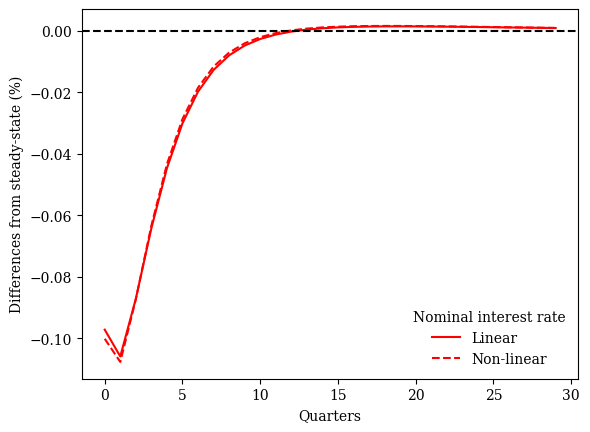

------ Figure 16d: Output ------


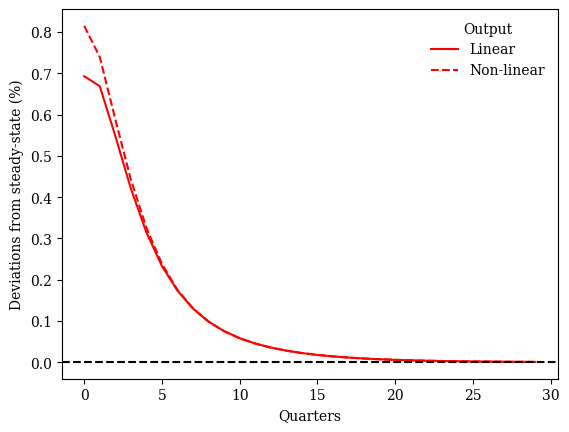

------ Figure 16e: Energy input ------


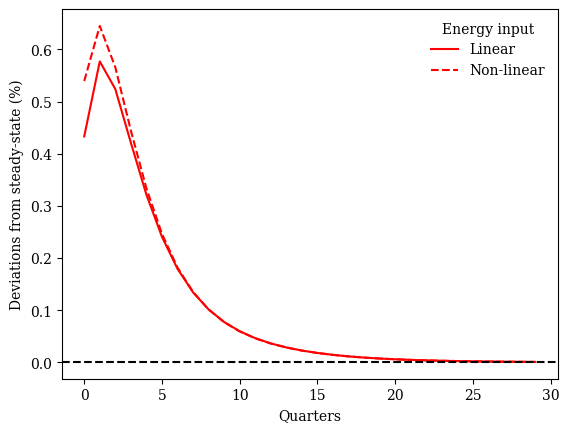

------ Figure 16f: Labor ------


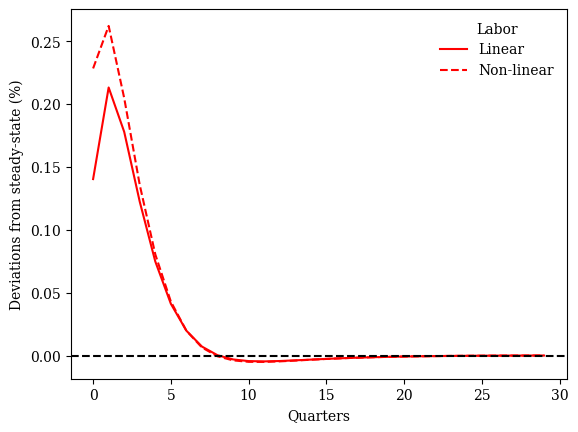

------ Figure 16g: Real wage ------


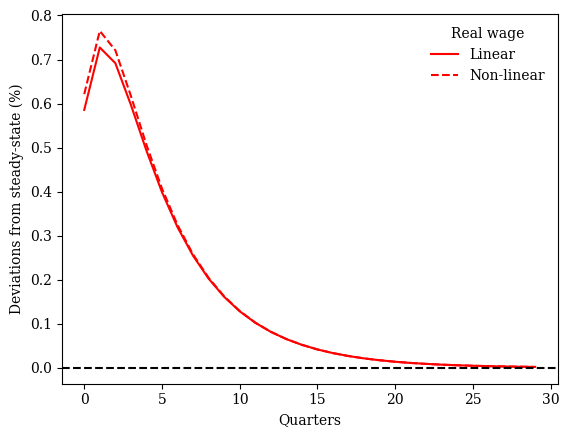

------ Figure 16h: Consumption ------


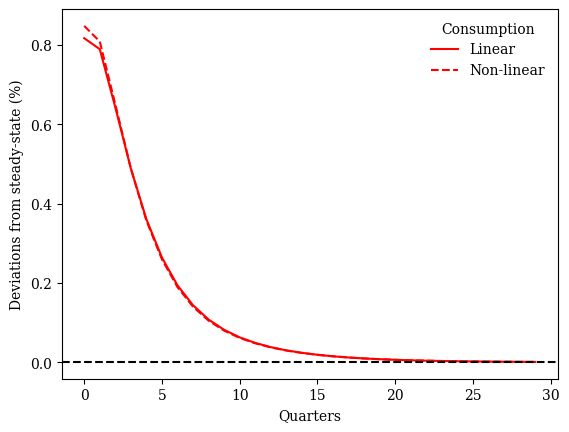

------ Figure 16i: Household energy consumption ------


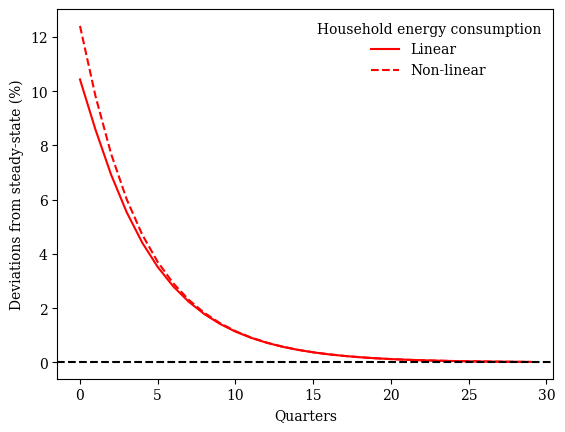

In [33]:
# Figure 16: Linear vs nonlinear IRFs (tariff shield shock only)
for i in range(len(var)):
    print('------ Figure 16'+string.ascii_lowercase[i]+': '+var_names[i]+' ------')
    if var[i] in ['pi', 'i', 'r']:
        plt.plot(100 * (irfs_ts[var[i]])[:truncated_T], color='red', label='Linear')
        plt.plot(100 * (irfs_ts_nl[var[i]])[:truncated_T], color='red', linestyle='--', label='Non-linear')
        plt.ylabel('Differences from steady-state (%)')
    else:
        plt.plot(100 * (irfs_ts[var[i]] / ss[var[i]])[:truncated_T], color='red', label='Linear')
        plt.plot(100 * (irfs_ts_nl[var[i]] / ss[var[i]])[:truncated_T], color='red', linestyle='--', label='Non-linear')
        plt.ylabel('Deviations from steady-state (%)')
    plt.axhline(0, linestyle='--', color='black')
    plt.xlabel('Quarters')
    plt.legend(frameon=False, title=var_names[i])
    if save_fig:
        plt.savefig('Figures/Figure16'+string.ascii_lowercase[i]+'.eps', dpi=500)
    plt.show()

### Energy + tariff shield shocks

In [34]:
# Linear IRFs
irfs = model.solve_impulse_linear(ss, unknowns=unknowns, targets=targets,
                                  inputs={'pFE': dpFE, 'subv': dsubv})

In [35]:
# Non-linear IRFs
irfs_nl = model.solve_impulse_nonlinear(ss, unknowns=unknowns, targets=targets,
                                        inputs={'pFE': dpFE, 'subv': dsubv})

Solving CepreHANK for ['pi', 'w', 'Y', 'Capprox', 'B', 'tauc', 'taul'] to hit ['nkpc_res', 'asset_mkt', 'labour_mkt', 'conso', 'debt_res', 'tauc_res', 'taul_res']
Solving monetary_inner for ['i'] to hit ['i_res']
On iteration 0
   max error for i_res is 0.00E+00
On iteration 0
   max error for nkpc_res is 6.37E-02
   max error for asset_mkt is 1.76E-01
   max error for labour_mkt is 4.02E-03
   max error for conso is 1.42E-02
   max error for debt_res is 1.92E-03
   max error for tauc_res is 7.38E-13
   max error for taul_res is 7.38E-13
Solving monetary_inner for ['i'] to hit ['i_res']
On iteration 0
   max error for i_res is 1.02E-02
On iteration 1
   max error for i_res is 3.47E-18
On iteration 1
   max error for nkpc_res is 1.35E-03
   max error for asset_mkt is 1.04E-02
   max error for labour_mkt is 2.07E-03
   max error for conso is 2.96E-03
   max error for debt_res is 1.22E-02
   max error for tauc_res is 2.37E-14
   max error for taul_res is 1.28E-14
Solving monetary_inner fo

------ Figure 17a: Subsidized energy price ------


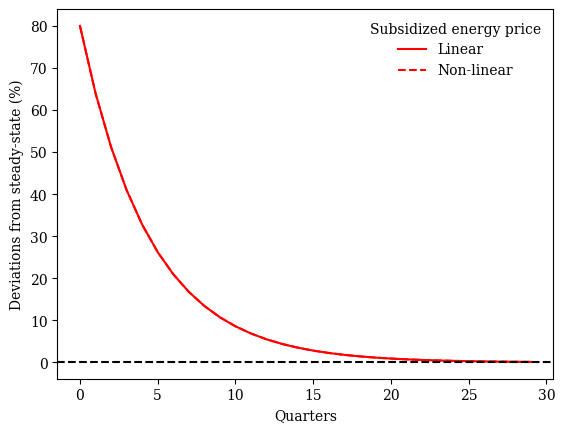

------ Figure 17b: Inflation ------


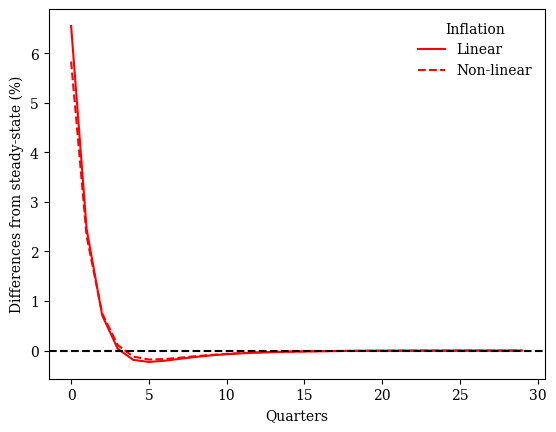

------ Figure 17c: Nominal interest rate ------


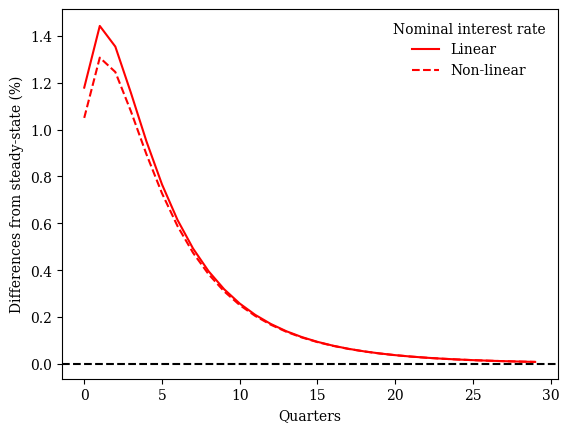

------ Figure 17d: Output ------


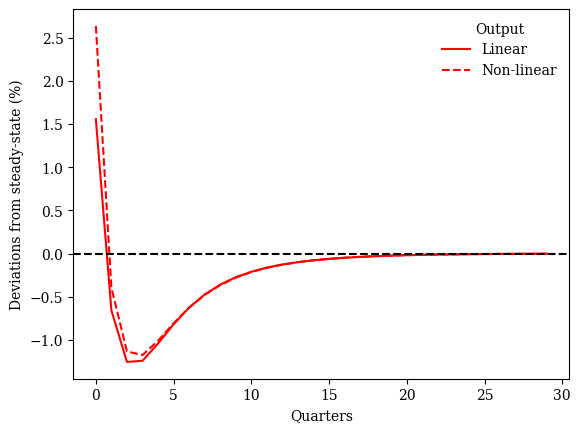

------ Figure 17e: Energy input ------


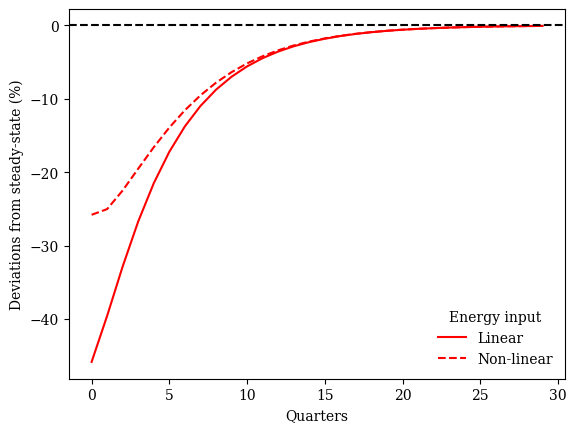

------ Figure 17f: Labor ------


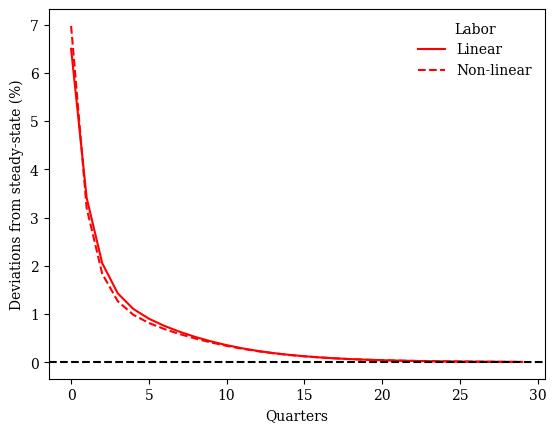

------ Figure 17g: Real wage ------


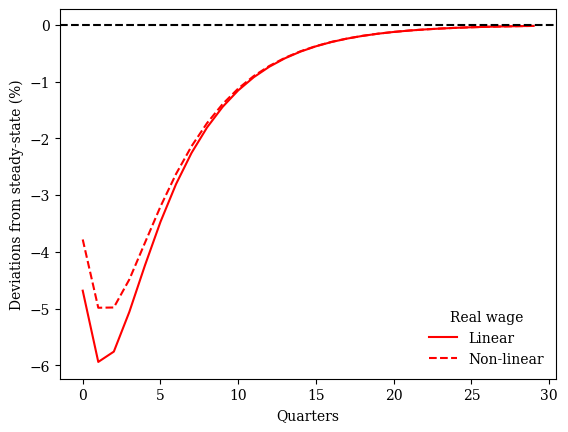

------ Figure 17h: Consumption ------


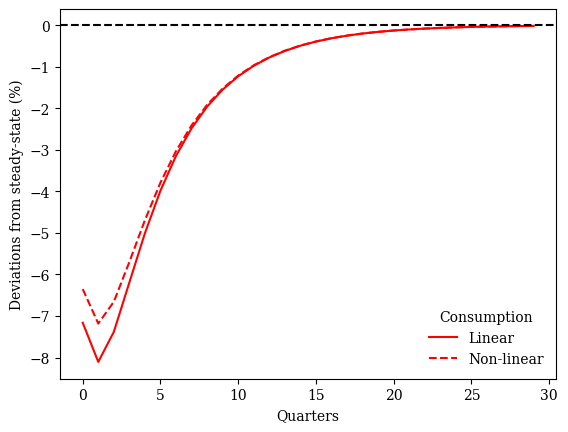

------ Figure 17i: Household energy consumption ------


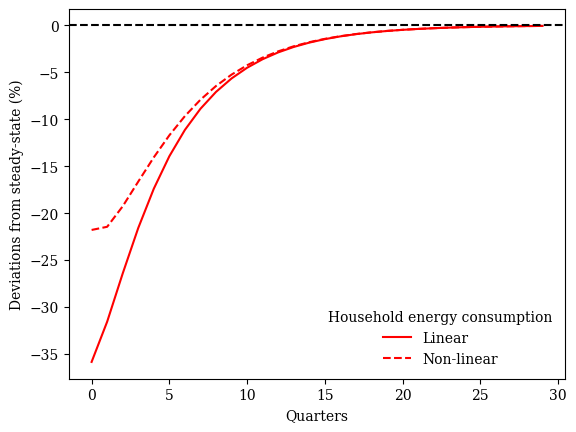

In [36]:
# Figure 17: Linear vs nonlinear IRFs (energy price + tariff shield)
for i in range(len(var)):
    print('------ Figure 17'+string.ascii_lowercase[i]+': '+var_names[i]+' ------')
    if var[i] in ['pi', 'i', 'r']:
        plt.plot(100 * (irfs[var[i]])[:truncated_T], color='red', label='Linear')
        plt.plot(100 * (irfs_nl[var[i]])[:truncated_T], color='red', linestyle='--', label='Non-linear')
        plt.ylabel('Differences from steady-state (%)')
    else:
        plt.plot(100 * (irfs[var[i]] / ss[var[i]])[:truncated_T], color='red', label='Linear')
        plt.plot(100 * (irfs_nl[var[i]] / ss[var[i]])[:truncated_T], color='red', linestyle='--', label='Non-linear')
        plt.ylabel('Deviations from steady-state (%)')
    plt.axhline(0, linestyle='--', color='black')
    plt.xlabel('Quarters')
    plt.legend(frameon=False, title=var_names[i])
    if save_fig:
        plt.savefig('Figures/Figure17'+string.ascii_lowercase[i]+'.eps', dpi=500)
    plt.show()

<a id="5-TS"></a>
## 5 Tariff shield effect

------ Figure 2a: Subsidized energy price ------


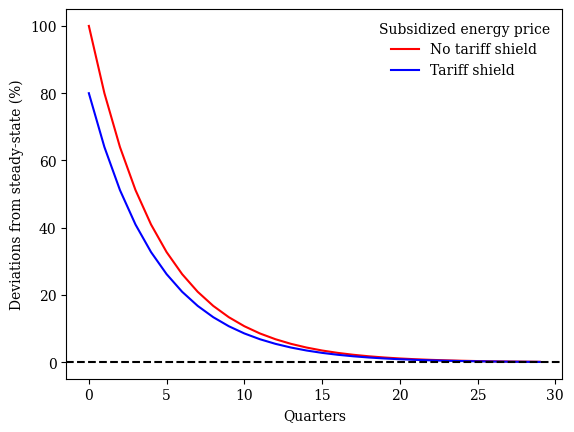

------ Figure 2b: Inflation ------


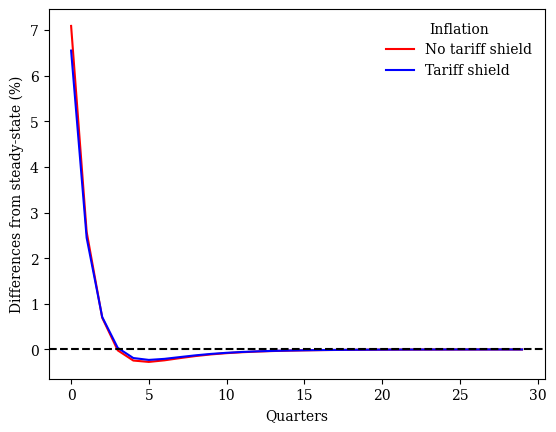

------ Figure 2c: Nominal interest rate ------


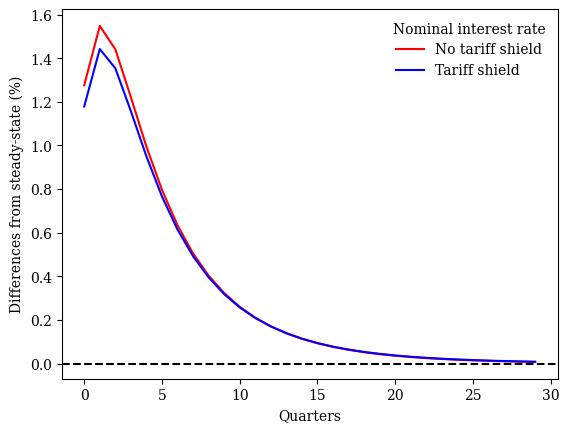

------ Figure 2d: Output ------


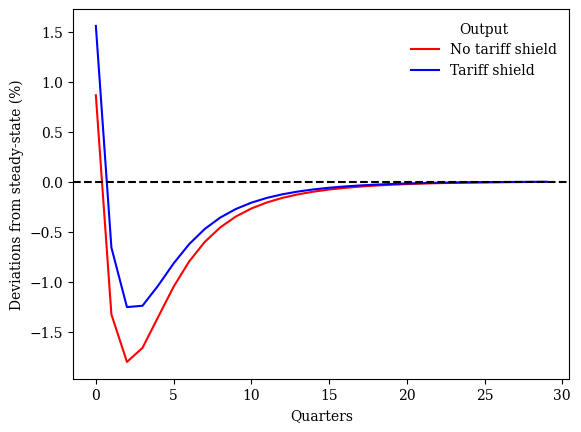

------ Figure 2e: Energy input ------


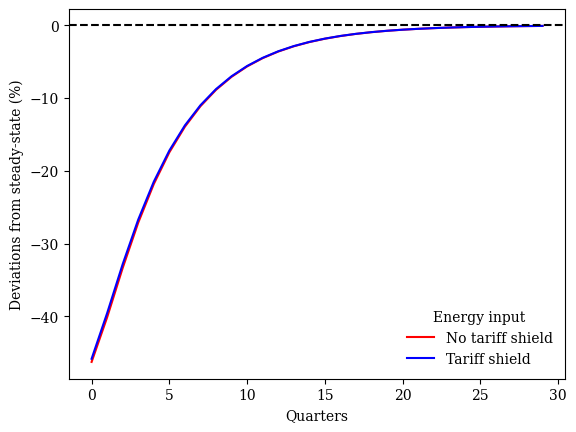

------ Figure 2f: Labor ------


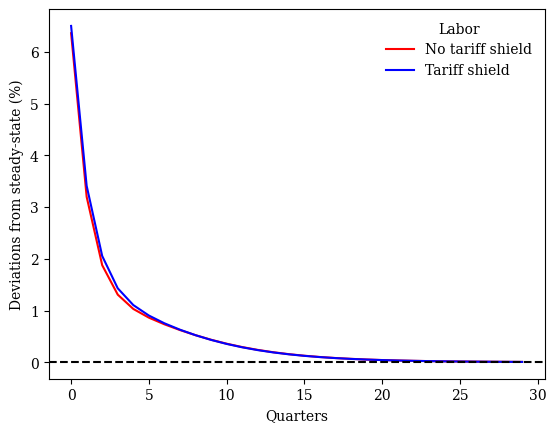

------ Figure 2g: Real wage ------


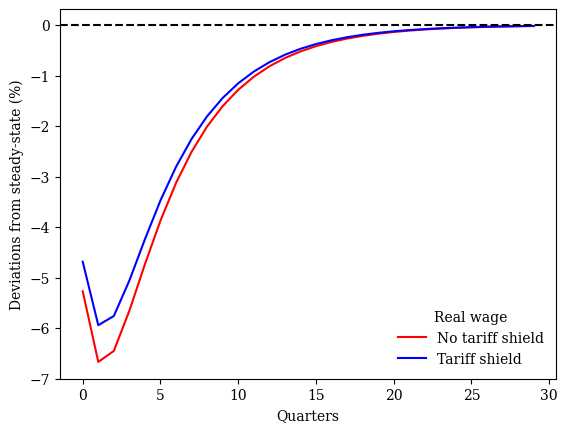

------ Figure 2h: Consumption ------


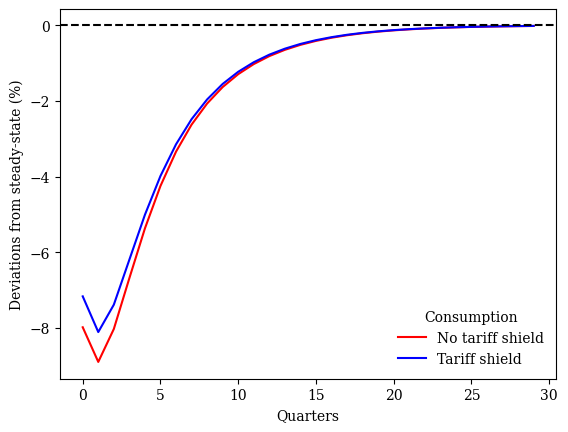

------ Figure 2i: Household energy consumption ------


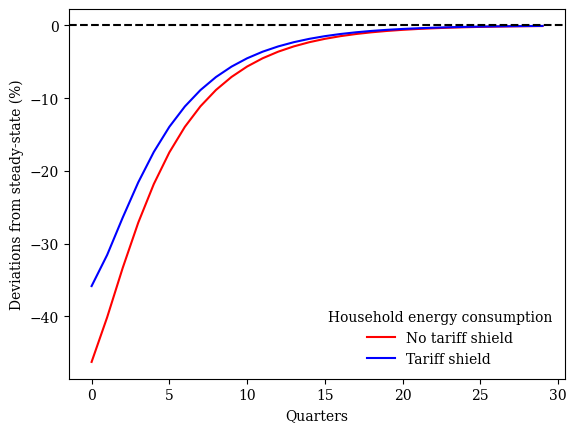

In [37]:
# Figure 2: IRFs to an energy shock with and without a tariff shield
for i in range(len(var)):
    print('------ Figure 2'+string.ascii_lowercase[i]+': '+var_names[i]+' ------')
    if var[i] in ['pi', 'i', 'r']:
        plt.plot(100 * (irfs_energy[var[i]])[:truncated_T], color='red', label='No tariff shield')
        plt.plot(100 * (irfs[var[i]])[:truncated_T], color='blue', label='Tariff shield')
        plt.ylabel('Differences from steady-state (%)')
    else:
        plt.plot(100 * (irfs_energy[var[i]] / ss[var[i]])[:truncated_T], color='red', label='No tariff shield')
        plt.plot(100 * (irfs[var[i]] / ss[var[i]])[:truncated_T], color='blue', label='Tariff shield')
        plt.ylabel('Deviations from steady-state (%)')
    plt.axhline(0, linestyle='--', color='black')
    plt.xlabel('Quarters')
    plt.legend(frameon=False, title=var_names[i])
    if save_fig:
        plt.savefig('Figures/Figure2'+string.ascii_lowercase[i]+'.eps', dpi=500)
    plt.show()

<a id="6-Ineq"></a>
## 6 Inequalities

In [38]:
colors = ['blue', '#7692FF', '#C2CEFF', 'black', '#FF9999', '#FF4747', 'red']

In [39]:
dTrans  = irf.shock_generator(ss, 'Subv', rho=.8, p=80/100, T=T, truncated_T=truncated_T, display=False).reshape(T)

In [40]:
# Linear IRFs
irfs_transfer = model.solve_impulse_linear(ss, unknowns=unknowns, targets=targets,
                                           inputs={'Subv': dTrans})

------ Figure 19: Consumption IRFs by productivity ------


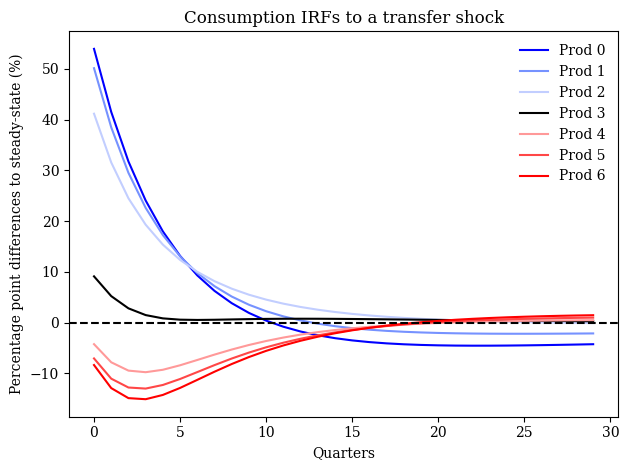

In [41]:
print('------ Figure 19: Consumption IRFs by productivity ------')
# Transfer shock
for j in range(7):
    dvar = irfs_transfer['C_' + str(j)] / (ss.internals['household']['pi_e'][j]) # Correcting by the mass of each productivity level
    # dvar = dvar / (np.abs(ss['C_' + str(j)]) / ss.internals['household']['pi_e'][j])
    dvar = 100*dvar
    plt.plot(dvar[:truncated_T], color=colors[j], label='Prod '+str(j))
plt.axhline(0, linestyle='--', color='black')
plt.legend(frameon=False)
plt.ylabel('Percentage point differences to steady-state (%)')
plt.xlabel('Quarters')
plt.title('Consumption IRFs to a transfer shock')
plt.tight_layout()
if save_fig:
    plt.savefig('Figures/Figure19.eps', dpi=500)
plt.show()